## PaddleOCR

⚠️ **NOTE**: It is for **PaddleOCR ≤ 3** versions.
🚨 **Version 3 introduces breaking changes!**

🔗 GitHub: [https://github.com/PaddlePaddle/PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR)


PaddleOCR is an open-source Optical Character Recognition (OCR) toolkit developed by the PaddlePaddle team.

### Main Features

* **Multilingual Support:** PaddleOCR supports over 80 languages, making it highly adaptable for diverse linguistic applications.
  *See:* *Multi-language model supported by PaddleOCR*
* **Comprehensive Model Suite:** The toolkit provides a wide range of models for text detection, text recognition, and layout analysis, including the flagship PP-OCR series.
* **Low-Code Development:** Tools such as PaddleX enable low-code development, allowing rapid deployment and easy customization of OCR workflows.

### Prerequisites

* Python ≥ 3.8.0
* Pip ≥ 24.0
* `PaddleOCR==2.10.0` (must be below 3.0)
* `paddlepaddle==3.2.2` (update if you encounter an *illegal instruction* error)

### References

* [PaddlePaddle Official Guide](https://www.paddlepaddle.org.cn/en/install/quick?docurl=/documentation/docs/en/install/pip/macos-pip_en.html)
* [PaddleOCR Official Documentation](https://paddlepaddle.github.io/PaddleOCR/main/en/index.html)

In [ ]:
import os
import cv2
from PIL import Image, ImageDraw, ImageFont
import numpy as np

from paddleocr import PaddleOCR

Shape of the image: (932, 1279, 3)


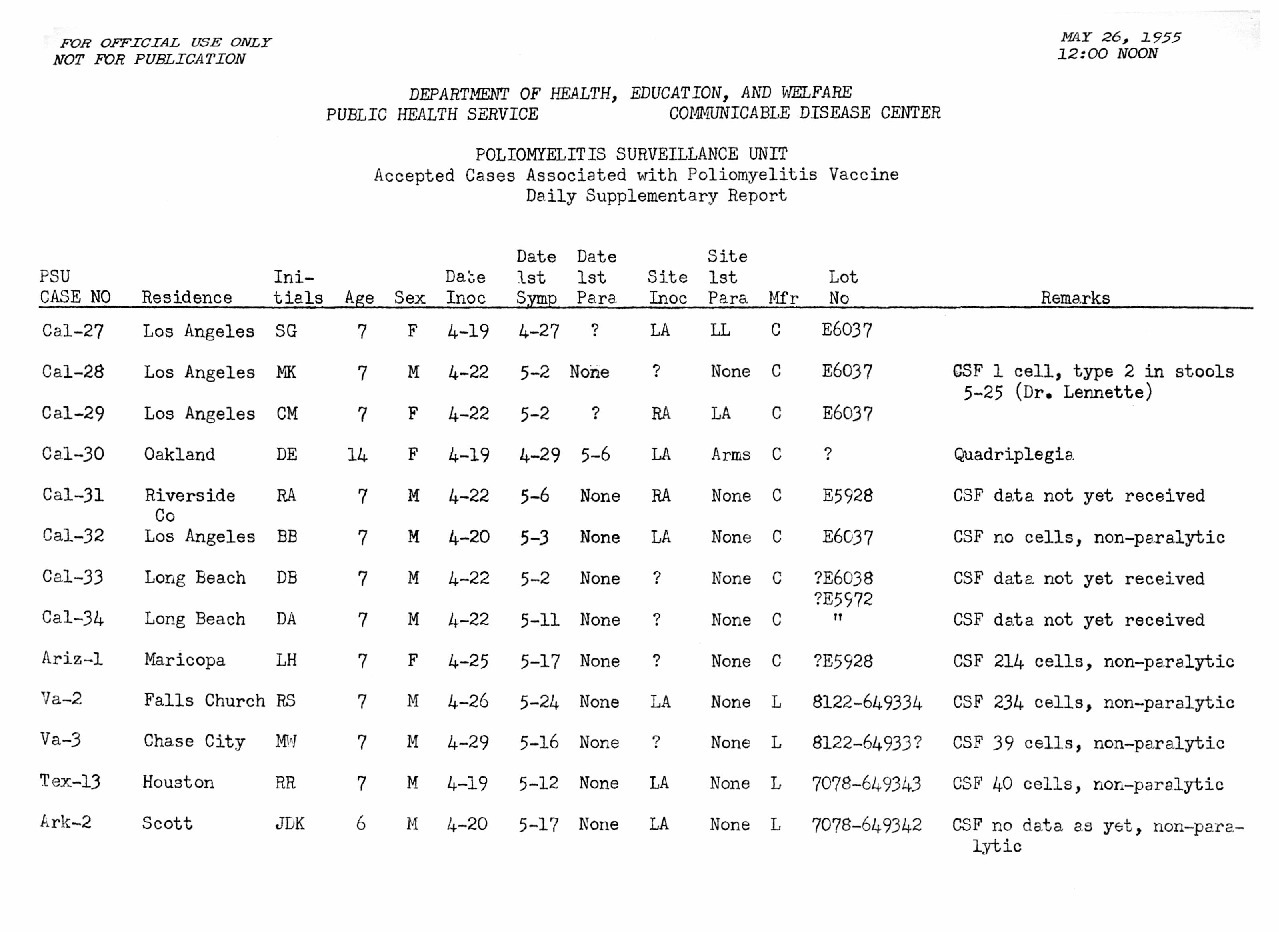

In [2]:
image_path = "./data/example-table.jpeg"
# Read the image as array
image_np = cv2.imread(image_path)
print(f"Shape of the image: {image_np.shape}")

# Display the image by converting the image_np to Image object
image = Image.fromarray(image_np)
image

In [3]:
# Model will be downloaded at location ~/.paddleocr/
ocr = PaddleOCR()

[2025/12/10 09:19:38] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/sanjeev/.paddleocr/whl/det/ch/ch_PP-OCRv4_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/sanjeev/.paddleocr/whl/rec/ch/ch_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_n

### Text Detection Only
- `ocr.text_detector` takes image as array as image of ndim 3, which is quite inconsistent with `.ocr` method which only takes `Image` or `str` path, not the `np.ndarray`

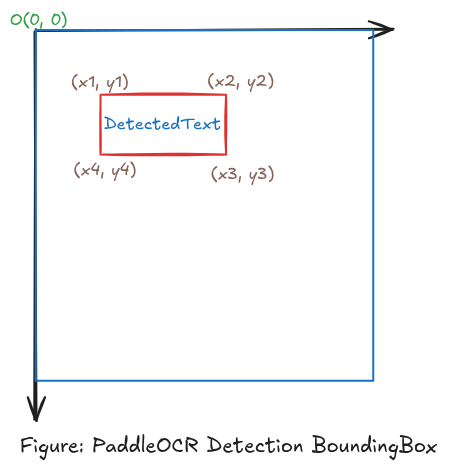

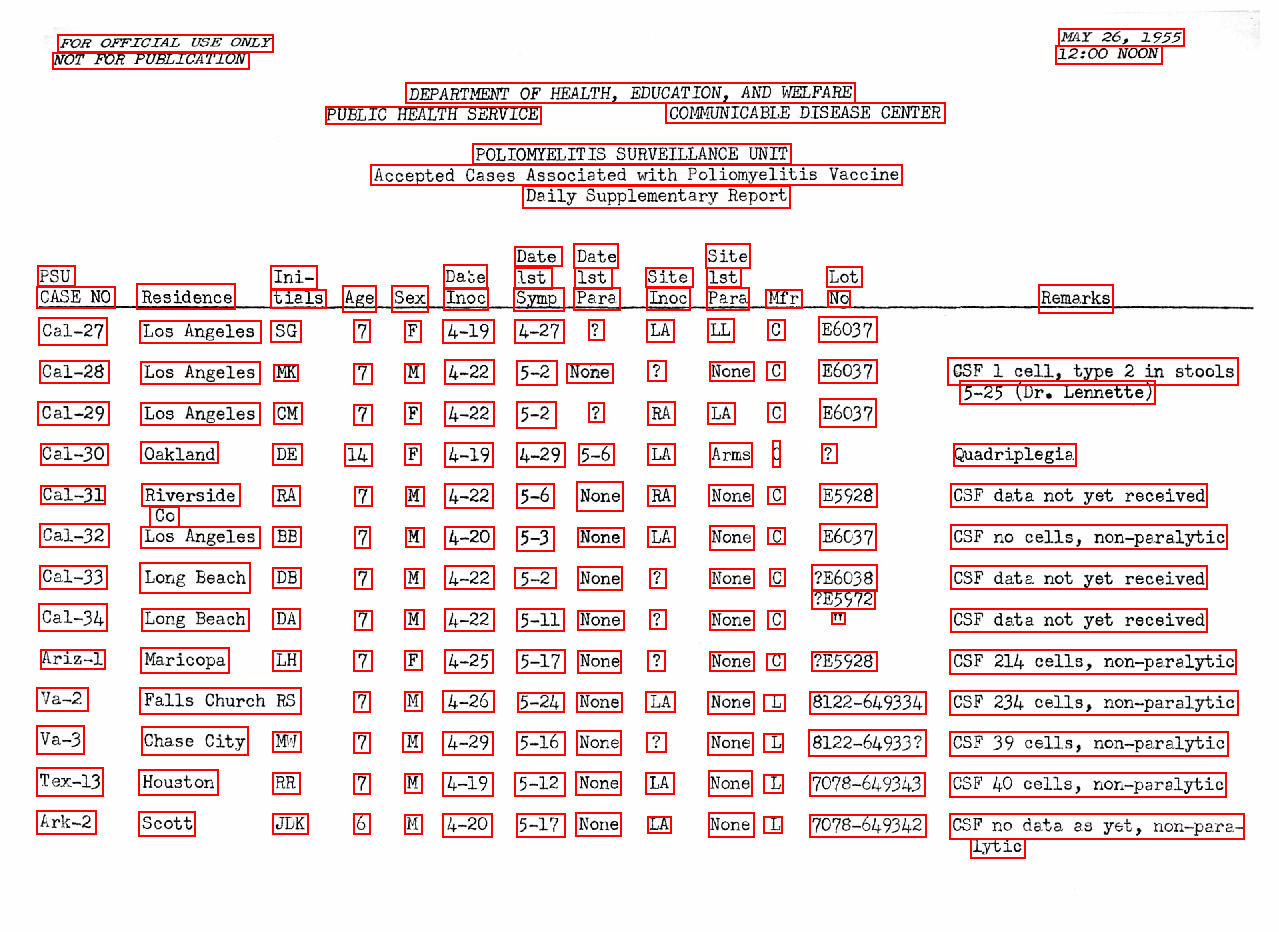

In [4]:
text_bboxes, _ = ocr.text_detector(image_np)

# Initiate new image object
image = Image.open(image_path).convert("RGB")
# Create a drawing context
draw = ImageDraw.Draw(image)

for bbox in text_bboxes:
    # bbox should be in the form of [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]
    # where (x1, y1) is the top-left corner and (x3, y3) is the bottom-right corner
    # Reformat the bbox to (left, top, right, bottom)
    top_left = bbox[0]
    bottom_right = bbox[2]
    reformat_bbox = [top_left[0], top_left[1], bottom_right[0], bottom_right[1]]

    # Draw the bounding box on the image
    draw.rectangle(reformat_bbox, outline="red", width=2)

# Show the image
image

### Direct OCR On the Image

[2025/12/10 09:19:38] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2025/12/10 09:19:39] ppocr DEBUG: dt_boxes num : 204, elapsed : 0.1673295497894287
[2025/12/10 09:19:44] ppocr DEBUG: rec_res num  : 204, elapsed : 5.310401439666748


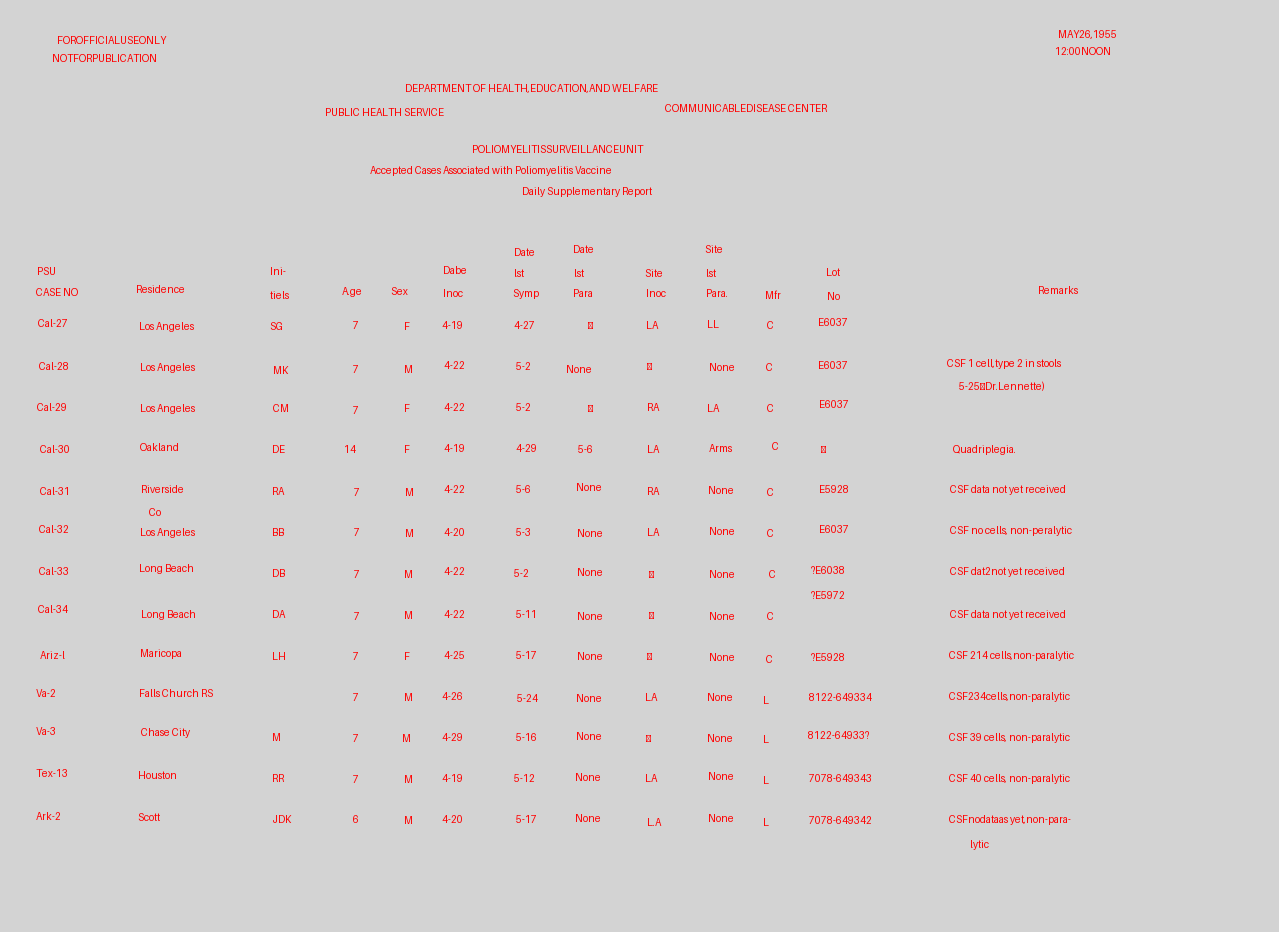

In [5]:
result = ocr.ocr(image_path)

# Initiate new blank image object
blank = Image.new("RGB", image.size, "LightGray")
draw = ImageDraw.Draw(blank)

for bboxes, (label, score) in result[0]:
    x_min, y_min = bboxes[0]
    x_max, y_max = bboxes[2]

    text = f"{label}" # Let's not display score now: {score:.2f}"

    font = ImageFont.load_default()

    text_position = (x_min, y_min)
    draw.text(text_position, text, fill="red", font=font)

blank

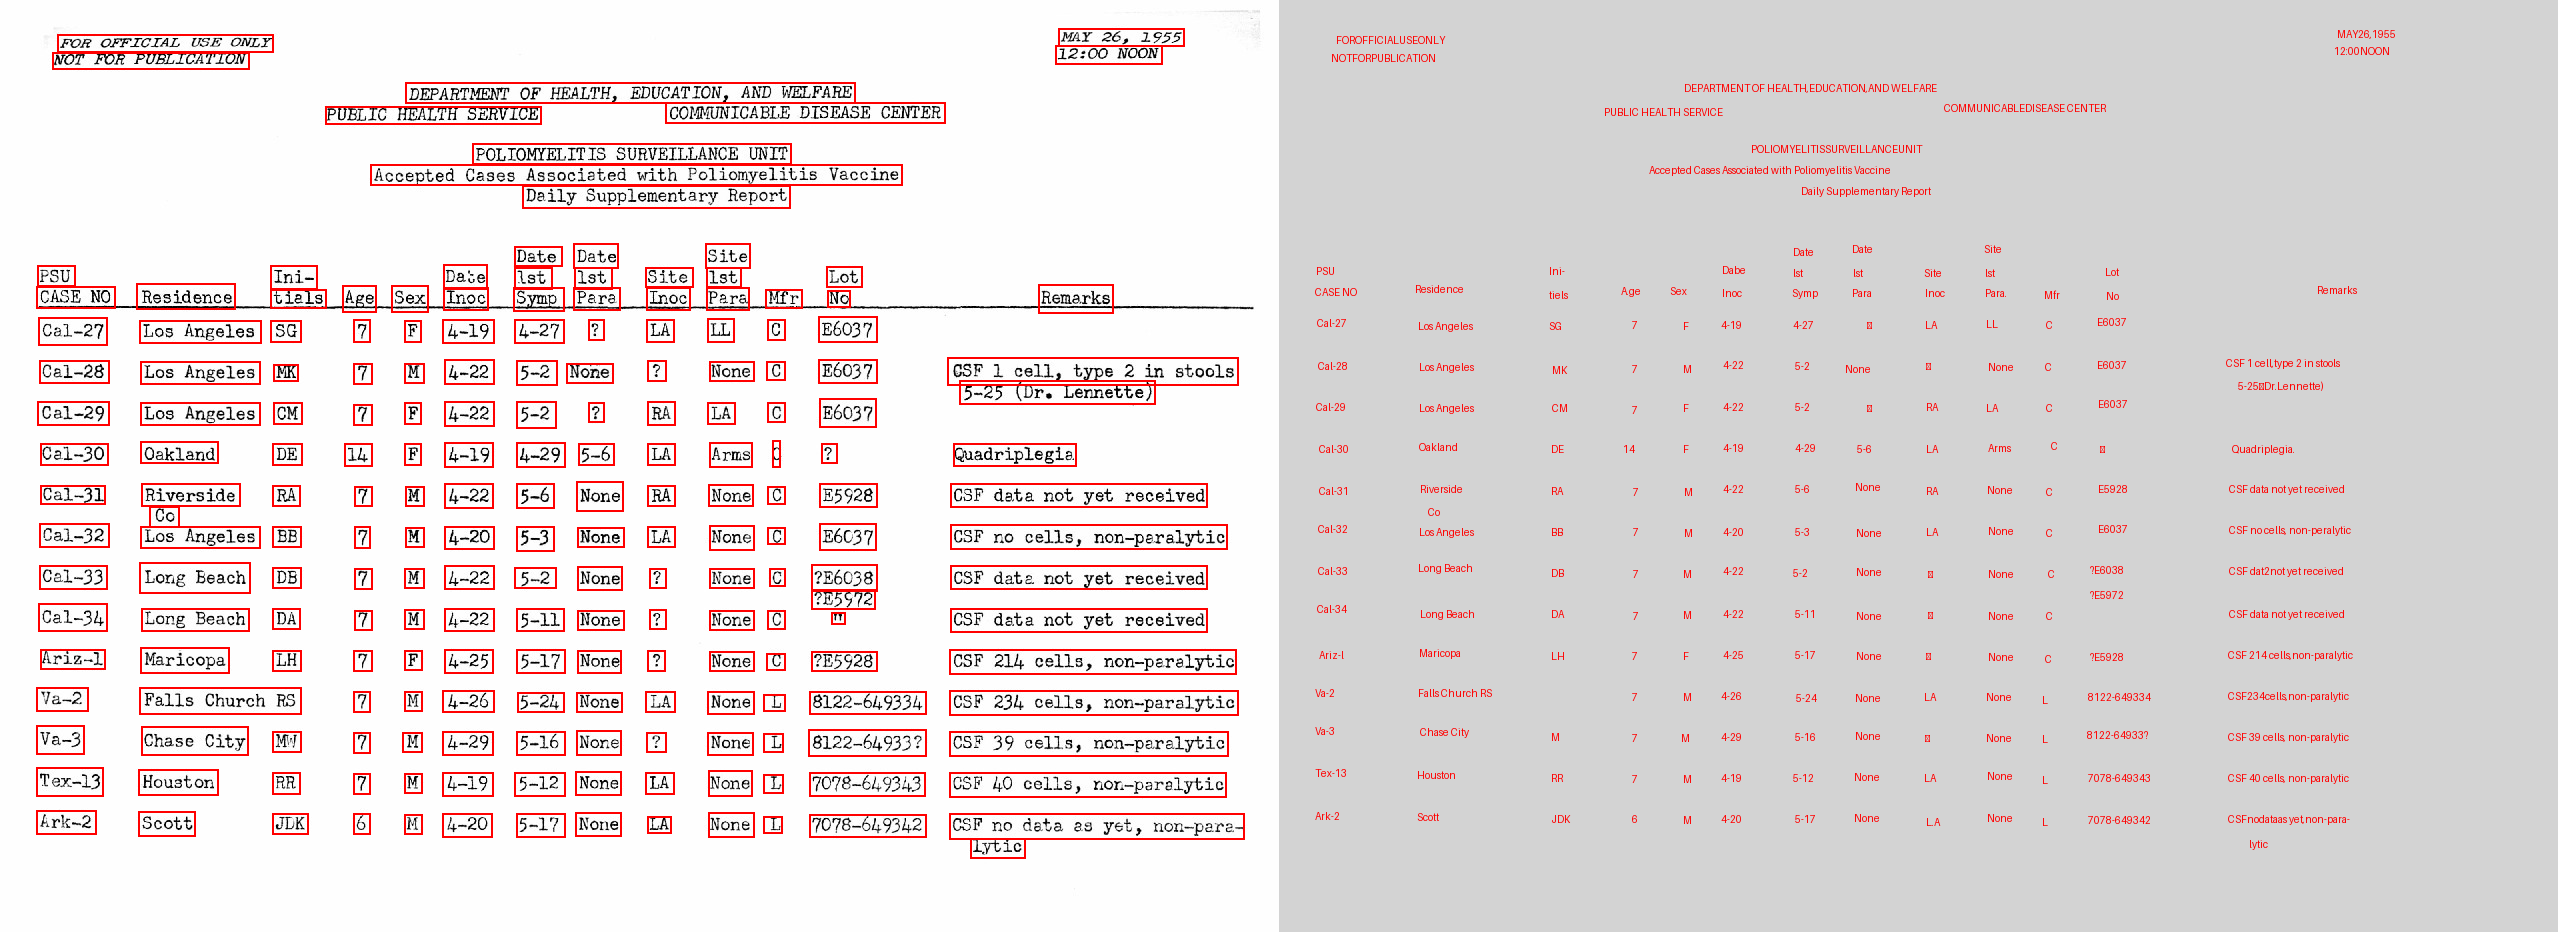

In [6]:
# image and ocr image side by side
w, h = image.size

combined = Image.new("RGB", (w*2, h), "white")

# Text detected image in left and OCR image in right
combined.paste(image, (0, 0))
combined.paste(blank, (w, 0))

combined